# UK TARIN RIDES

In [158]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")


In [ ]:
#read data
data=pd.read_csv("railway.csv")
data.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


## Data Preprocessing

In [160]:
data.duplicated().sum()

0

In [161]:
data.isnull().sum()

Transaction ID             0
Date of Purchase           0
Time of Purchase           0
Purchase Type              0
Payment Method             0
Railcard               20918
Ticket Class               0
Ticket Type                0
Price                      0
Departure Station          0
Arrival Destination        0
Date of Journey            0
Departure Time             0
Arrival Time               0
Actual Arrival Time     1880
Journey Status             0
Reason for Delay       27481
Refund Request             0
dtype: int64

In [162]:
data.fillna({'Railcard':'No Railcard'}, inplace=True)

In [163]:
#explore null values journey status
print(data.loc[data['Actual Arrival Time'].isnull(), 'Journey Status'].unique())


['Cancelled']


In [164]:
#fill missing value
data.fillna({'Reason for Delay': 'Not Delayed'}, inplace=True)

# Apply lower and strip, and save it back to the column
data['Reason for Delay'] = data['Reason for Delay'].str.lower().str.strip()

# Check the unique values in the column
data['Reason for Delay'].unique()

array(['not delayed', 'signal failure', 'technical issue',
       'weather conditions', 'weather', 'staffing', 'staff shortage',
       'traffic'], dtype=object)

In [165]:
#adjusting format
map = {
    'weather conditions': 'weather',
    'staffing': 'staff shortage'
}
data['Reason for Delay'] = data['Reason for Delay'].replace(map)
data['Reason for Delay'].unique()

array(['not delayed', 'signal failure', 'technical issue', 'weather',
       'staff shortage', 'traffic'], dtype=object)

In [166]:
# Ensure time columns are parsed correctly
data['Departure Time'] = pd.to_datetime(data['Departure Time'], format='%H:%M:%S').dt.time
data['Arrival Time'] = pd.to_datetime(data['Arrival Time'], format='%H:%M:%S').dt.time

# Ensure date is in datetime format
data['Date of Journey'] = pd.to_datetime(data['Date of Journey'])

# Combine date and time to full datetime
data['Departure Time'] = pd.to_datetime(data['Date of Journey'].astype(str) + ' ' + data['Departure Time'].astype(str))
data['Arrival Time'] = pd.to_datetime(data['Date of Journey'].astype(str) + ' ' + data['Arrival Time'].astype(str))

# Handle overnight trips (arrival is on the next day)
data.loc[data['Arrival Time'] < data['Departure Time'], 'Arrival Time'] += pd.Timedelta(days=1)

# Calculate the duration
data['Trip Duration(hrs)'] = data['Arrival Time'] - data['Departure Time']
# Trip duration in hours
data['Trip Duration(hrs)'] = (data['Trip Duration(hrs)'].dt.total_seconds() / 3600).round(2)

In [167]:
# Make sure Actual Arrival Time is in time format
data['Actual Arrival Time'] = pd.to_datetime(data['Actual Arrival Time'], format='%H:%M:%S', errors='coerce').dt.time

# Combine date with actual arrival time to make full datetime
data['Actual Arrival Time'] = pd.to_datetime(data['Date of Journey'].astype(str) + ' ' + data['Actual Arrival Time'].astype(str), errors='coerce')

# Handle overnight actual arrivals (if any)
data.loc[data['Actual Arrival Time'] < data['Arrival Time'], 'Actual Arrival Time'] += pd.Timedelta(days=1)

# Calculate the delay
data['Delay (min)'] = data['Actual Arrival Time'] - data['Arrival Time']
# Delay in minutes
data['Delay (min)'] = data['Delay (min)'].dt.total_seconds() / 60

data.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Trip Duration(hrs),Delay (min)
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,2024-01-01 11:00:00,2024-01-01 13:30:00,2024-01-01 13:30:00,On Time,not delayed,No,2.50,0.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,2024-01-01 09:45:00,2024-01-01 11:35:00,2024-01-01 11:40:00,Delayed,signal failure,No,1.83,5.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,No Railcard,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,2024-01-02 18:15:00,2024-01-02 18:45:00,2024-01-02 18:45:00,On Time,not delayed,No,0.50,0.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,No Railcard,Standard,Advance,13,London Paddington,Reading,2024-01-01,2024-01-01 21:30:00,2024-01-01 22:30:00,2024-01-01 22:30:00,On Time,not delayed,No,1.00,0.0
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,No Railcard,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,2024-01-01 16:45:00,2024-01-01 19:00:00,2024-01-01 19:00:00,On Time,not delayed,No,2.25,0.0


In [168]:
data.fillna({'Actual Arrival Time': 'Cancelled'}, inplace=True)
data['Delay (min)'] = data['Delay (min)'].fillna(-1)

In [169]:
#exploring data
data.describe()

,Price,Date of Journey,Departure Time,Arrival Time,Trip Duration(hrs),Delay (min)
count,31653.000000,31653,31653,31653,31653.000000,31653.000000
mean,23.439200,2024-03-01 08:01:10.969576192,2024-03-01 20:03:02.826272256,2024-03-01 21:14:12.080371456,1.184394,2.997283
min,1.000000,2024-01-01 00:00:00,2024-01-01 00:00:00,2024-01-01 00:30:00,0.250000,-1.000000
25%,5.000000,2024-01-31 00:00:00,2024-01-31 08:00:00,2024-01-31 09:20:00,0.500000,0.000000
50%,11.000000,2024-03-01 00:00:00,2024-03-01 22:15:00,2024-03-02 00:05:00,1.330000,0.000000
75%,35.000000,2024-03-31 00:00:00,2024-03-31 13:15:00,2024-03-31 14:20:00,1.500000,0.000000
max,267.000000,2024-04-30 00:00:00,2024-04-30 23:45:00,2024-05-01 01:45:00,4.500000,180.000000
std,29.997628,NaN,NaN,NaN,0.604683,14.360343


In [170]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       31653 non-null  object        
 1   Date of Purchase     31653 non-null  object        
 2   Time of Purchase     31653 non-null  object        
 3   Purchase Type        31653 non-null  object        
 4   Payment Method       31653 non-null  object        
 5   Railcard             31653 non-null  object        
 6   Ticket Class         31653 non-null  object        
 7   Ticket Type          31653 non-null  object        
 8   Price                31653 non-null  int64         
 9   Departure Station    31653 non-null  object        
 10  Arrival Destination  31653 non-null  object        
 11  Date of Journey      31653 non-null  datetime64[ns]
 12  Departure Time       31653 non-null  datetime64[ns]
 13  Arrival Time         31653 non-

In [171]:
#extract cleaned data to file
data.to_csv(r"C:\Users\BCC\Downloads\outcome.csv", index=False)


## Data Analysis

### Q1: How punctual is the UK train?

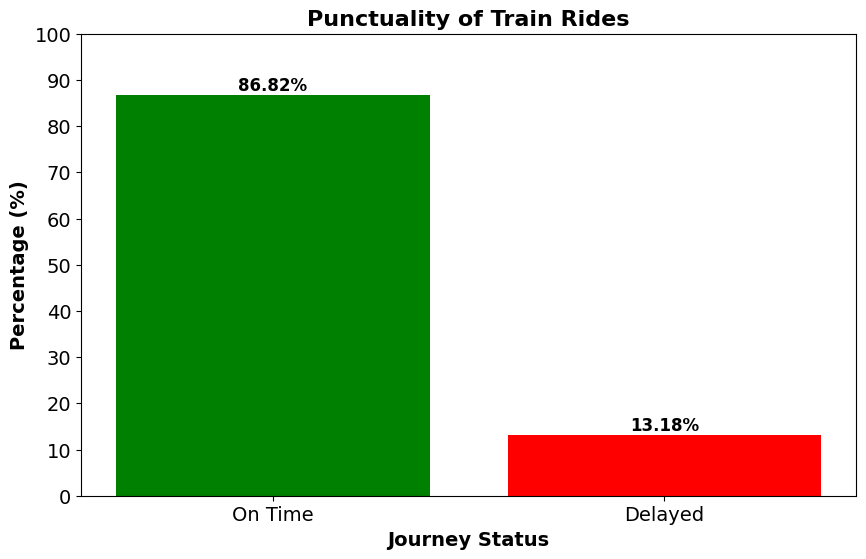

In [172]:
# count on_time and delayed trips
status_on_time = ["On Time"]

on_time_count = data[data["Journey Status"].isin(status_on_time)].shape[0]
delayed_count = data.shape[0] - on_time_count

# Calculate percentages
on_time_percentage = (on_time_count / data.shape[0]) * 100
delayed_percentage = (delayed_count / data.shape[0]) * 100

# Create bar chart
labels = ['On Time', 'Delayed']
percentages = [on_time_percentage, delayed_percentage]

plt.figure(figsize=(10,6))
plt.bar(labels, percentages, color=['green', 'red'])
plt.title('Punctuality of Train Rides', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(range(0, 101, 10), fontsize=14)
plt.xlabel('Journey Status', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
# Add percentage on top of bars:
for i, v in enumerate(percentages):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontsize=12, fontweight='bold')
plt.show()


### Q2: The different paying methods

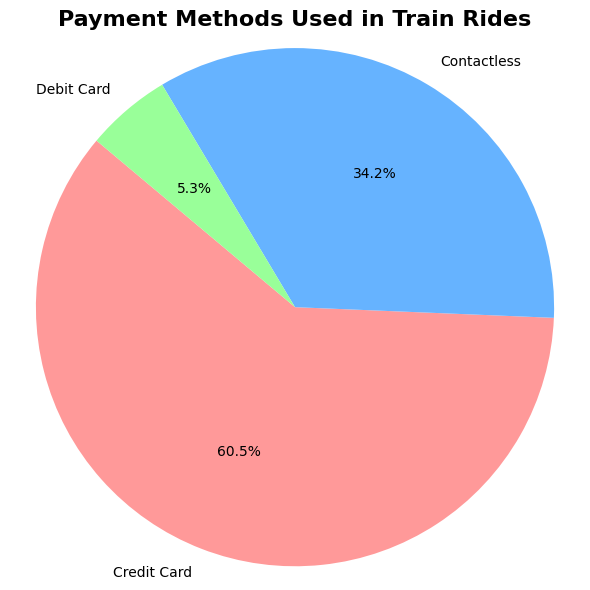

In [173]:
# what are the different paying methods?
data["Payment Method"].value_counts()
# count the percentage of each payment method
payment_100 = data["Payment Method"].value_counts(normalize=True) * 100

# Create a pie chart for payment methods
plt.figure(figsize=(6, 6))
plt.pie(payment_100, labels=payment_100.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Payment Methods Used in Train Rides', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

### Q3: The different classes in the train

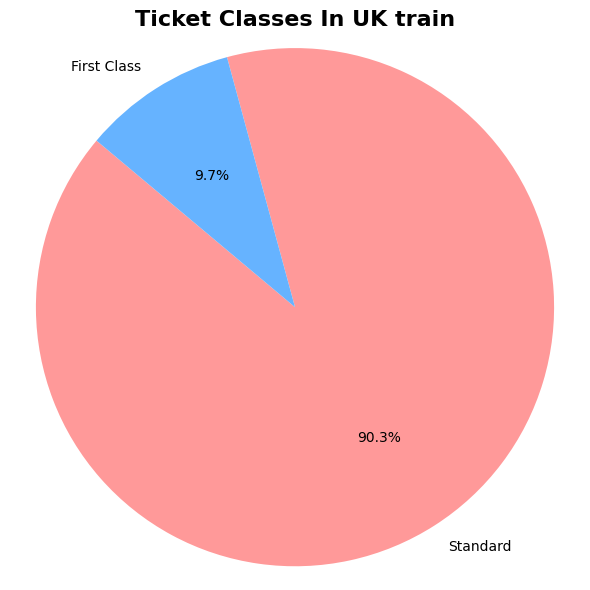

In [174]:
# whta are the differner classes in the train?
data["Ticket Class"].value_counts()
# calculate the percentage of each ticket class:
ticket_class_100 = data["Ticket Class"].value_counts(normalize=True) * 100

# Create a pie chart for ticket classes
plt.figure(figsize=(6, 6))
plt.pie(ticket_class_100, labels=ticket_class_100.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Ticket Classes In UK train', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()



### Q4:Distribution of Purchase Type

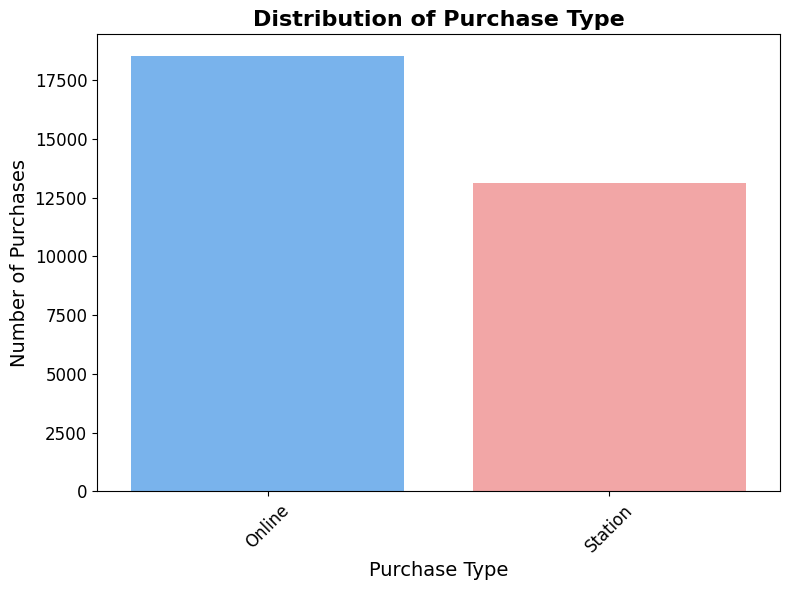

In [175]:
# Define your color palette
colors = ['#66b3ff', '#ff9999', '#99ff99']  # Modify as needed to match purchase types

# Create the countplot
plt.figure(figsize=(8, 6))
sns.countplot(
    data=data,
    x='Purchase Type',
    hue='Purchase Type',
    order=data['Purchase Type'].value_counts().index,
    palette=colors,
    legend=False
)

# Customize plot
plt.title('Distribution of Purchase Type', fontsize=16, fontweight='bold')
plt.xlabel('Purchase Type', fontsize=14)
plt.ylabel('Number of Purchases', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


### Q5: the highest_traffic arrival destinations vs lowest_traffic 

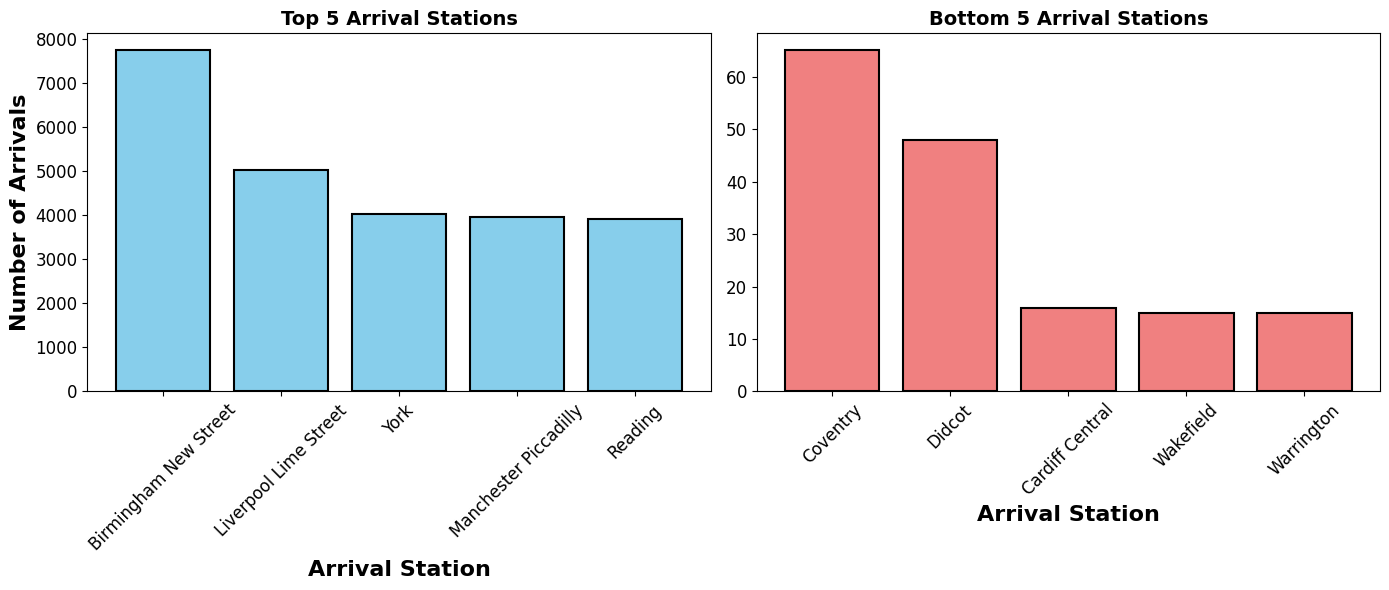

In [176]:
# Top and bottom 5 arrival destinations
top_5_arrivals = data["Arrival Destination"].value_counts().head(5)
bottom_5_arrivals = data["Arrival Destination"].value_counts().tail(5)

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left chart: Top 5
axes[0].bar(top_5_arrivals.index, top_5_arrivals.values,
            color='skyblue', edgecolor='black', linewidth=1.5)
axes[0].set_title('Top 5 Arrival Stations', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Arrival Station', fontweight='bold',fontsize=16)
axes[0].set_ylabel('Number of Arrivals', fontweight='bold', fontsize=16)
axes[0].tick_params(axis='x', rotation=45, labelsize=12,)
axes[0].tick_params(axis='y', labelsize=12)

# Right chart: Bottom 5
axes[1].bar(bottom_5_arrivals.index, bottom_5_arrivals.values,
            color='lightcoral', edgecolor='black', linewidth=1.5)
axes[1].set_title('Bottom 5 Arrival Stations', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Arrival Station', fontweight='bold',fontsize=16)
axes[1].tick_params(axis='x', rotation=45, labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

### Q6:Delay time by Reason for Delay

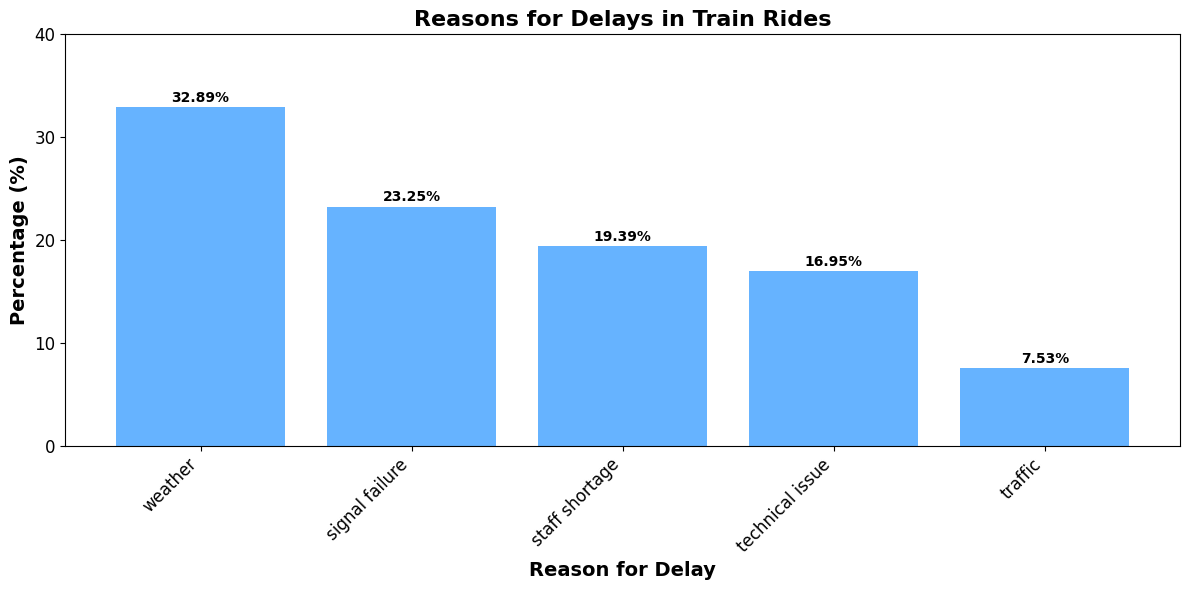

In [177]:
# What are the different types of delays?
delayed_rides = data["Reason for Delay"] != "not delayed"

# Count the number of each type of delay
delay_counts = data[delayed_rides]["Reason for Delay"].value_counts()

# Calculate the percentage of each type of delay
delay_percentages = (delay_counts / delay_counts.sum()) * 100

# Create a bar chart for delay reasons
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(delay_counts.index, delay_percentages, color='#66b3ff')

plt.title('Reasons for Delays in Train Rides', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)

# Set fewer y-axis ticks and limit the range to just above the max value
plt.ylim(0, 40)  # Adjust depending on your data max (e.g., if top is ~33%)
plt.yticks(ticks=range(0, 41, 10), fontsize=12)

plt.xlabel('Reason for Delay', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=14, fontweight='bold')

# Add percentage labels above bars
for i, v in enumerate(delay_percentages):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### Q7:Average price in the First class vs standard

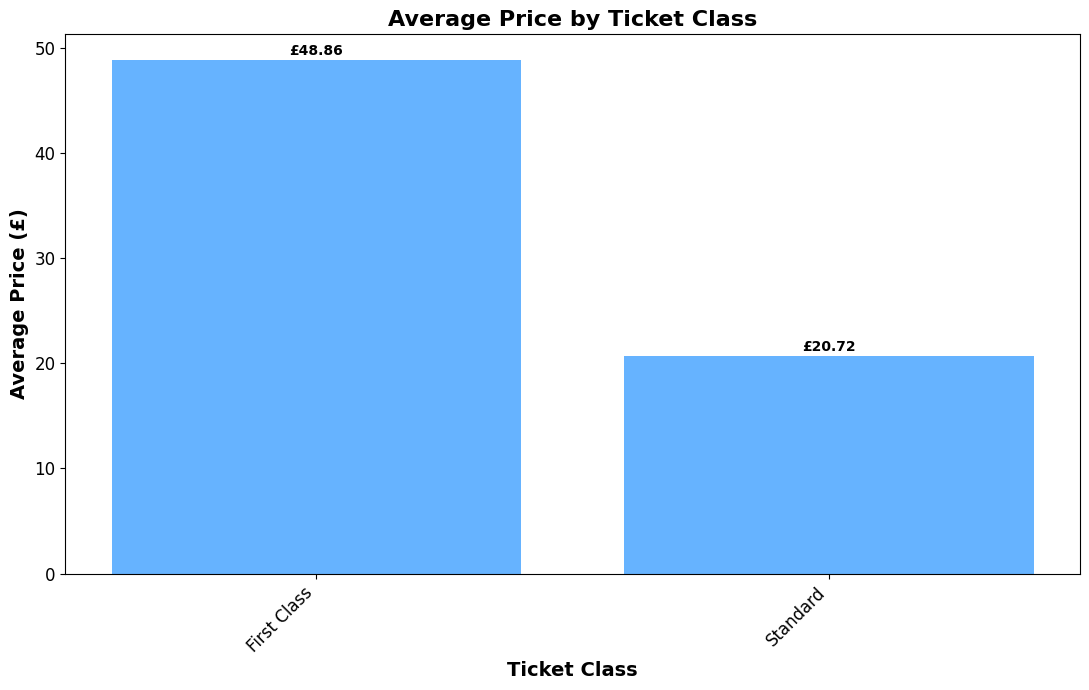

In [178]:
# group the data by the ticket class and calculate the average price for each class
average_price_by_class = data.groupby("Ticket Class")["Price"].mean()
# sort the data by average price in descending order
average_price_by_class = average_price_by_class.sort_values(ascending=False)
# Create a bar chart for average price by ticket class
plt.figure(figsize=(11, 7))
plt.bar(average_price_by_class.index, average_price_by_class.values, color='#66b3ff')
plt.title('Average Price by Ticket Class', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Ticket Class', fontsize=14, fontweight='bold')
plt.ylabel('Average Price (£)', fontsize=14, fontweight='bold')
# Add average price on top of bars:
for i, v in enumerate(average_price_by_class.values):
    plt.text(i, v + 0.5, f"£{v:.2f}", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


### Q8: Average price for the highest_traffic arrival destinations vs for the lowest_traffic

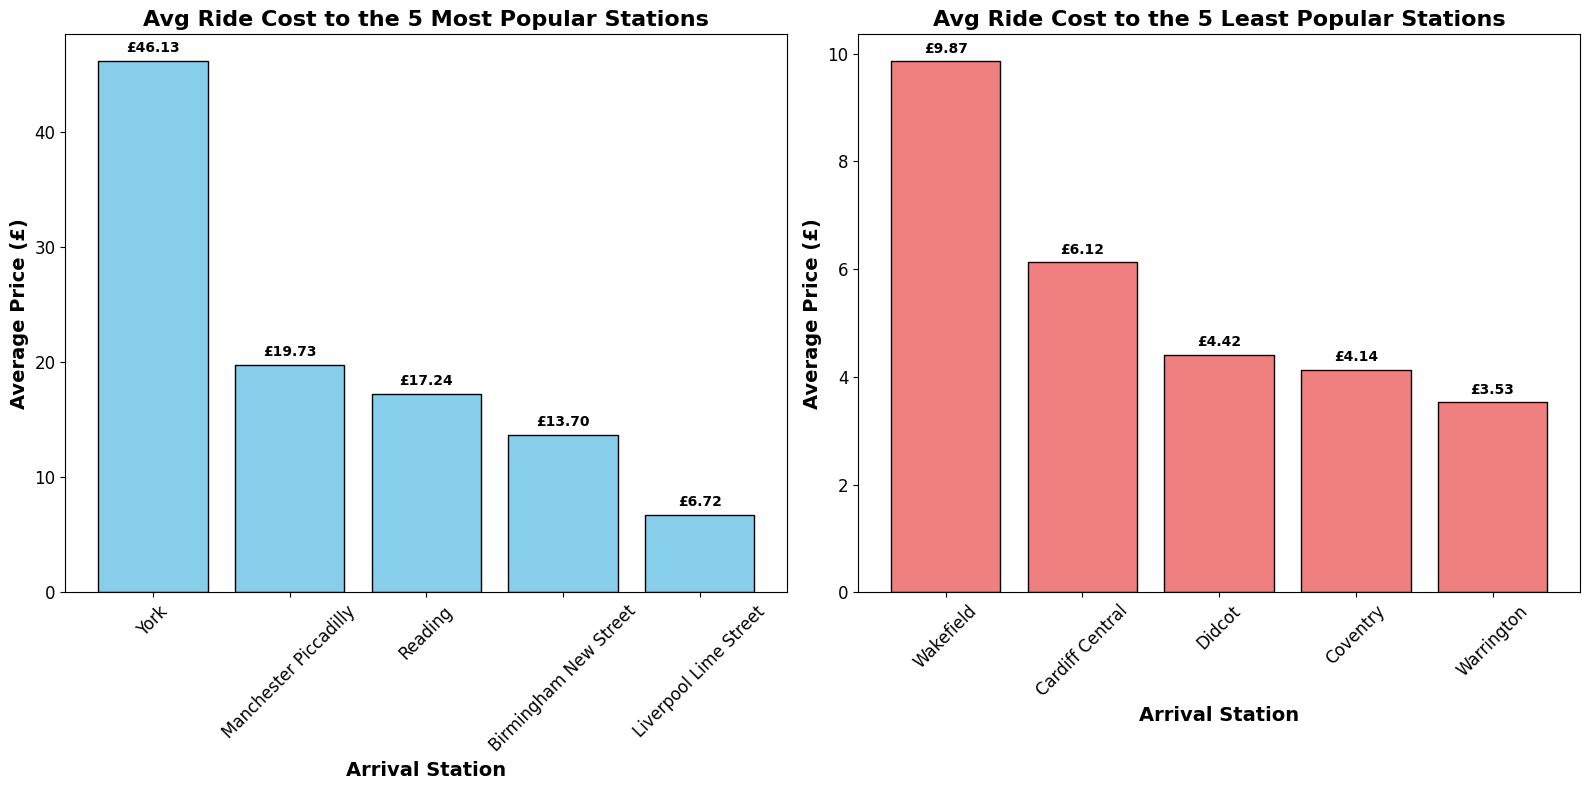

In [179]:
# combine the top and bottom 5 arrival stations into a list to get the average prices:
# Top and bottom 5 arrival destinations
top_5_arrivals = data["Arrival Destination"].value_counts().head(5)
bottom_5_arrivals = data["Arrival Destination"].value_counts().tail(5)
# Combine the two lists
combined_arrivals = list(top_5_arrivals.index) + list(bottom_5_arrivals.index)
# the average prices of the combined arrivals list:
average_prices = data[data["Arrival Destination"].isin(combined_arrivals)].groupby("Arrival Destination")["Price"].mean().sort_values(ascending=False)

# Separate the top and bottom average prices from the combined sorted list
top_5_prices = average_prices.loc[top_5_arrivals.index]
bottom_5_prices = average_prices.loc[bottom_5_arrivals.index]

# Sort both series in descending order
top_5_prices = top_5_prices.sort_values(ascending=False)
bottom_5_prices = bottom_5_prices.sort_values(ascending=False)


# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left chart: Top 5
axes[0].bar(top_5_prices.index, top_5_prices.values, color='skyblue', edgecolor='black')
axes[0].set_title("Avg Ride Cost to the 5 Most Popular Stations", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Arrival Station", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Average Price (£)", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=12)
axes[0].tick_params(axis='y', labelsize=12)
# add the cost of the rides to the top of the bars
for i, v in enumerate(top_5_prices.values):
    axes[0].text(i, v + 0.5, f'£{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right chart: Bottom 5
axes[1].bar(bottom_5_prices.index, bottom_5_prices.values, color='lightcoral', edgecolor='black')
axes[1].set_title("Avg Ride Cost to the 5 Least Popular Stations", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Arrival Station", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Average Price (£)", fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)
# add the cost of the rides to the top of the bars
for i, v in enumerate(bottom_5_prices.values):
    axes[1].text(i, v + 0.1, f'£{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



### Q9: Traffic trend over the months

In [180]:
# the time frame of the rides the data set covers:
print(data['Date of Journey'].max())
print(data['Date of Journey'].min())
# the time frame of the rides is from January 2024 to April 2024.

2024-04-30 00:00:00
2024-01-01 00:00:00


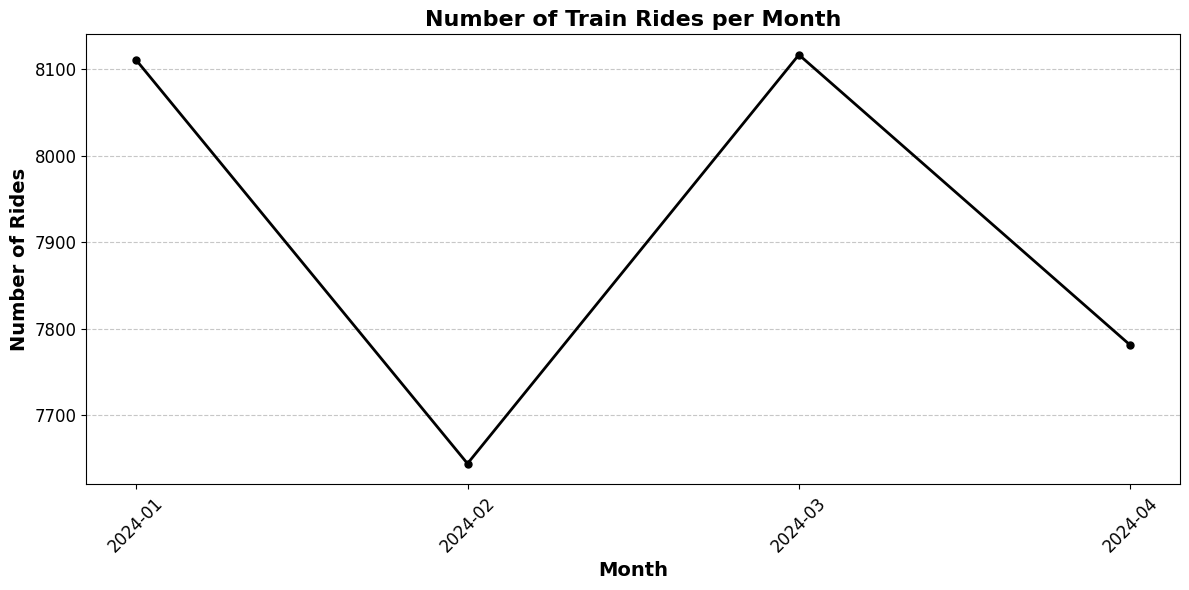

In [181]:
# Ensure 'Date of Journey' is datetime
d = pd.DataFrame()
d["Month"] = data["Date of Journey"].dt.to_period("M").astype(str)
 
#create a line chart:
plt.figure(figsize=(12, 6))
plt.plot(d["Month"].value_counts().sort_index(), marker='o', linestyle='-', color='black', linewidth=2, markersize=5)
plt.title("Number of Train Rides per Month", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=14, fontweight='bold')
plt.ylabel("Number of Rides", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Q10: How does ticket class vary across departure stations, and which stations contribute highest revenue?

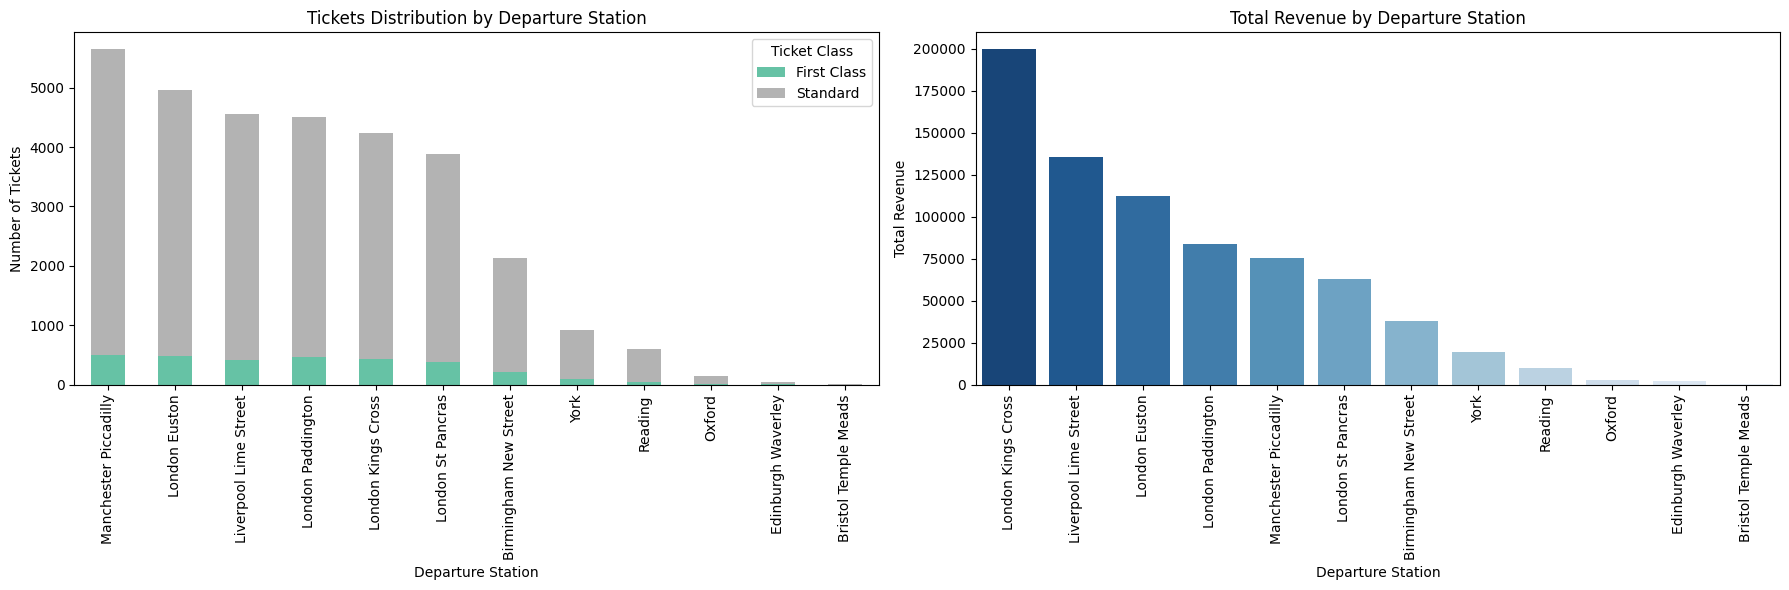

In [182]:
# Group by Departure Station and Ticket Class, then count
ticket_counts = data.groupby(['Departure Station', 'Ticket Class']).size().reset_index(name='Count')

# Create pivot table for plotting
pivot_table = ticket_counts.pivot(index='Departure Station', columns='Ticket Class', values='Count')

# Sort departure stations by total ticket count (descending)
total_counts = pivot_table.sum(axis=1)
pivot_table = pivot_table.loc[total_counts.sort_values(ascending=False).index]

# Group by Departure Station and sum the Price
station_revenue = data.groupby('Departure Station')['Price'].sum().sort_values(ascending=False)

# Create subplots (1 row, 2 columns) for horizontal layout
fig, axes = plt.subplots(1, 2, figsize=(18, 6))  # Adjusted figure size for side-by-side plots

# Plotting Ticket Class Distribution by Departure Station (Stacked Bar)
pivot_table.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[0])
axes[0].set_title('Tickets Distribution by Departure Station')
axes[0].set_xlabel('Departure Station')
axes[0].set_ylabel('Number of Tickets')
axes[0].legend(title='Ticket Class')
axes[0].tick_params(axis='x', rotation=90)

# Plotting Total Revenue by Departure Station (Vertical Bar Plot)
sns.barplot(x=station_revenue.index, y=station_revenue.values,hue=station_revenue.index, palette='Blues_r', legend=False, ax=axes[1])
axes[1].set_title('Total Revenue by Departure Station')
axes[1].set_xlabel('Departure Station')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()


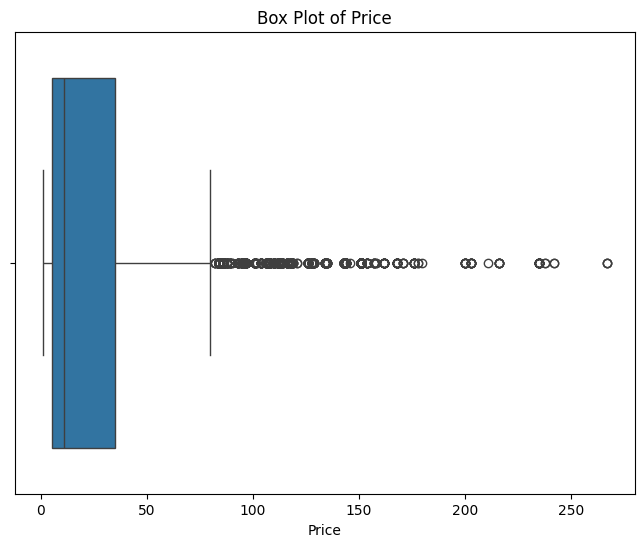

In [183]:
# Create a box plot for the 'Price' column
plt.figure(figsize=(8, 6))  # Adjust the figure size if needed
sns.boxplot(x=data['Price'])
# Add labels and title
plt.title('Box Plot of Price')
plt.xlabel('Price')
# Show the plot
plt.show()


<Axes: xlabel='Price', ylabel='Count'>

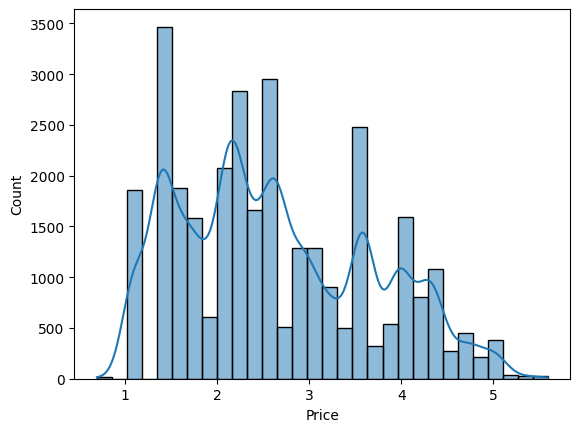

In [184]:
df = data.copy()
df['Price'] = np.log1p(df['Price'])
sns.histplot(df['Price'], bins=30, kde=True)

In [185]:
from sklearn.preprocessing import LabelEncoder

cols_to_encode = [
    'Purchase Type', 'Payment Method', 'Railcard', 'Ticket Class', 'Ticket Type',
    'Departure Station', 'Arrival Destination', 'Journey Status',
    'Reason for Delay', 'Refund Request'
]

# Dictionary to store encoders for each column
encoders = {}

# Apply label encoding and store mappings
for col in cols_to_encode:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le  # Save encoder for this column
        
        # Print label mapping
        print(f"\nEncoding for '{col}':")
        for class_index, class_label in enumerate(le.classes_):
            print(f"  {class_label} → {class_index}")



Encoding for 'Purchase Type':
  Online → 0
  Station → 1

Encoding for 'Payment Method':
  Contactless → 0
  Credit Card → 1
  Debit Card → 2

Encoding for 'Railcard':
  Adult → 0
  Disabled → 1
  No Railcard → 2
  Senior → 3

Encoding for 'Ticket Class':
  First Class → 0
  Standard → 1

Encoding for 'Ticket Type':
  Advance → 0
  Anytime → 1
  Off-Peak → 2

Encoding for 'Departure Station':
  Birmingham New Street → 0
  Bristol Temple Meads → 1
  Edinburgh Waverley → 2
  Liverpool Lime Street → 3
  London Euston → 4
  London Kings Cross → 5
  London Paddington → 6
  London St Pancras → 7
  Manchester Piccadilly → 8
  Oxford → 9
  Reading → 10
  York → 11

Encoding for 'Arrival Destination':
  Birmingham New Street → 0
  Bristol Temple Meads → 1
  Cardiff Central → 2
  Coventry → 3
  Crewe → 4
  Didcot → 5
  Doncaster → 6
  Durham → 7
  Edinburgh → 8
  Edinburgh Waverley → 9
  Leeds → 10
  Leicester → 11
  Liverpool Lime Street → 12
  London Euston → 13
  London Kings Cross → 14
  Lo

## Forecasting& Prediction

In [186]:
# Assuming 'df' is your original DataFrame
daily_revenue = df.groupby('Date of Journey')['Price'].sum().reset_index()
daily_revenue.columns = ['Date', 'Revenue']

# Feature engineering
daily_revenue['Month'] = daily_revenue['Date'].dt.month
daily_revenue['Weekday'] = daily_revenue['Date'].dt.weekday
daily_revenue['Day'] = daily_revenue['Date'].dt.day
daily_revenue['Prev_Revenue'] = daily_revenue['Revenue'].shift(1)  # Previous day's revenue
daily_revenue['Month_to_Month_Change'] = daily_revenue['Revenue'].pct_change()  # Percentage change in revenue month to month
daily_revenue['Week_of_Year'] = daily_revenue['Date'].dt.isocalendar().week  # Week number of the year

# Fill missing values after feature engineering
daily_revenue.fillna(0, inplace=True)

# Features and target
X = daily_revenue[['Month', 'Weekday', 'Day', 'Prev_Revenue', 'Month_to_Month_Change', 'Week_of_Year']]
y = daily_revenue['Revenue']

# Train-test split (last month as test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

# Train model with the best hyperparameters from GridSearchCV
model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='auto',
    random_state=42
)

model.fit(X_train, y_train)

# Evaluate model
preds = model.predict(X_test)

# Calculate RMSE and R² score for the test set
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2_test = r2_score(y_test, preds)

print(f"RMSE (Test Set): {rmse:.2f}")
print(f"R² (Test Set): {r2_test:.2f}")

# Create future dates (May to Oct 2024)
future_dates = pd.date_range(start='2024-05-01', end='2024-10-31')

# Get the last known revenue to use as 'Prev_Revenue' for the first future day
last_known_revenue = daily_revenue['Revenue'].iloc[-1]

# Create feature dataframe for future predictions
future_df = pd.DataFrame({
    'Date': future_dates,
    'Month': future_dates.month,
    'Weekday': future_dates.weekday,
    'Day': future_dates.day,
    'Prev_Revenue': last_known_revenue,  # Use the last known revenue
    'Month_to_Month_Change': 0.05,  # Placeholder, can adjust based on expected trend
    'Week_of_Year': future_dates.isocalendar().week
})

# Predict future revenue
future_revenue = model.predict(future_df[['Month', 'Weekday', 'Day', 'Prev_Revenue', 'Month_to_Month_Change', 'Week_of_Year']])
future_df['Predicted Revenue'] = future_revenue

# Show predictions without index
print(future_df[['Date', 'Predicted Revenue']].head().to_string(index=False, float_format='{:,.2f}'.format))



RMSE (Test Set): 22.60
R² (Test Set): 0.81
      Date  Predicted Revenue
2024-05-01             422.34
2024-05-02             571.20
2024-05-03             722.04
2024-05-04             722.28
2024-05-05             721.24


In [187]:
# Group actual revenue by month
monthly_revenue = daily_revenue.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue.columns = ['Month', 'Actual Revenue']

# Group predicted revenue by month (from historical data)
daily_revenue['Predicted Revenue'] = model.predict(X)
monthly_predicted = daily_revenue.groupby('Month')['Predicted Revenue'].sum().reset_index()
monthly_predicted.columns = ['Month', 'Predicted Revenue']

# Merge only actual and predicted revenue
merged = monthly_revenue.merge(monthly_predicted, on='Month', how='inner').sort_values(by='Month')

# Print nicely formatted table
print("\n Actual vs Predicted Revenue by Month:")
print(merged.to_string(index=False, float_format='{:,.2f}'.format))

forecasted_monthly_revenue = future_df.groupby('Month')['Predicted Revenue'].sum().reset_index()

# Print the forecasted revenue for each month (May to Oct 2024)
print("\nForecasted Revenue by Month (May to Oct 2024):")
print(forecasted_monthly_revenue.to_string(index=False, float_format='{:,.2f}'.format))


 Actual vs Predicted Revenue by Month:
 Month  Actual Revenue  Predicted Revenue
     1       21,601.81          21,567.26
     2       19,487.26          19,358.80
     3       21,561.83          21,560.14
     4       20,667.96          20,726.78

Forecasted Revenue by Month (May to Oct 2024):
 Month  Predicted Revenue
     5          21,957.76
     6          21,249.80
     7          21,907.33
     8          21,968.11
     9          21,218.06
    10          21,932.16


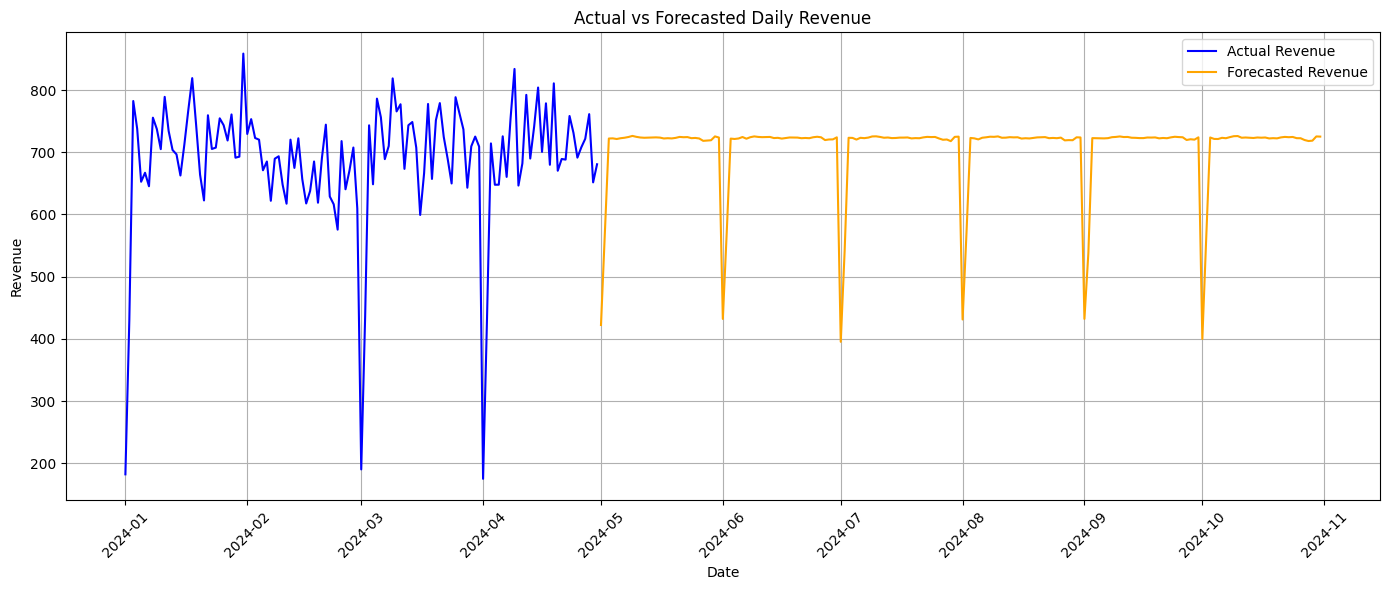

In [188]:
daily_revenue['Date'] = pd.to_datetime(daily_revenue['Date'])
future_df['Date'] = pd.to_datetime(future_df['Date'])

# Create the plot
plt.figure(figsize=(14, 6))

# Plot historical revenue
plt.plot(daily_revenue['Date'], daily_revenue['Revenue'], label='Actual Revenue', color='blue')

# Plot forecasted revenue
plt.plot(future_df['Date'], future_df['Predicted Revenue'], label='Forecasted Revenue', color='orange')

# Add plot details
plt.title("Actual vs Forecasted Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)


Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best hyperparameters: {'max_depth': 10, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [189]:
df.drop(columns=[col for col in ['Transaction ID','Actual Arrival Time','Date of Purchase','Date of Journey','Departure Time','Time of Purchase','Arrival Time'] if col in df.columns], inplace=True)

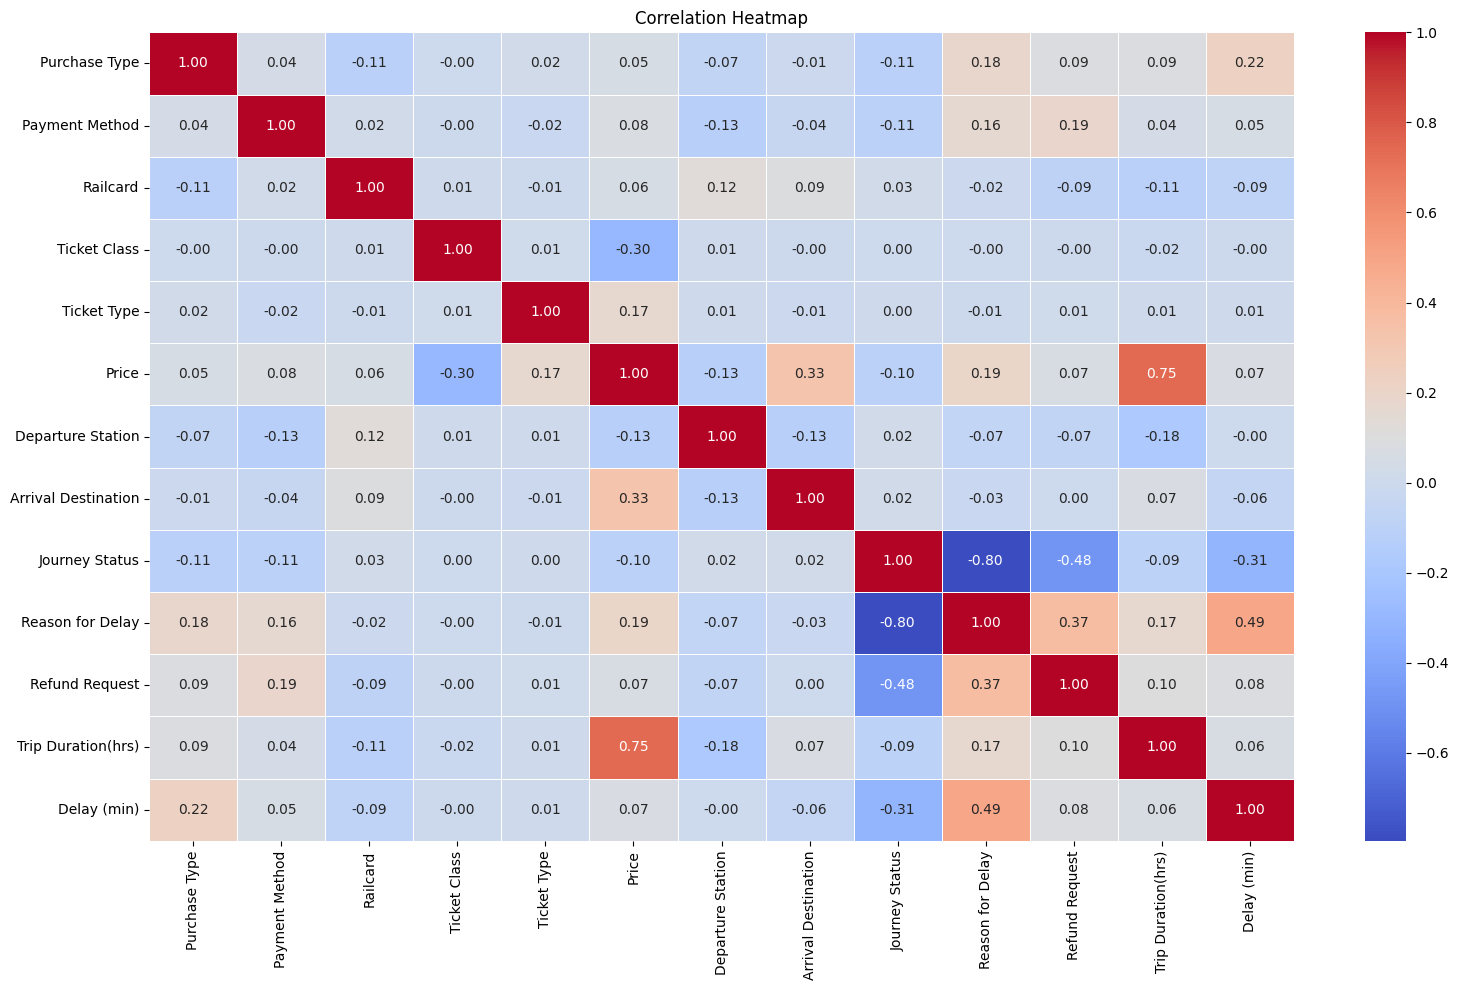

In [190]:
corr_matrix = df.corr()
# Plot heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Define features and target
X = df.drop(columns=['Price','Journey Status','Reason for Delay','Refund Request','Delay (min)'])
y = df['Price']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    r_train = np.corrcoef(y_train, y_train_pred)[0, 1]

    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r_test = np.corrcoef(y_test, y_test_pred)[0, 1]

    print(f"\n {name} - Training Set:")
    print(f"  MAE: {mae_train:.2f}")
    print(f"  MSE: {mse_train:.2f}")
    print(f"  R: {r_train:.2f}")

    print(f"\n {name} - Testing Set:")
    print(f"  MAE: {mae_test:.2f}")
    print(f"  MSE: {mse_test:.2f}")
    print(f"  R: {r_test:.2f}")

# Random Forest
evaluate_model(RandomForestRegressor(n_estimators=100,max_depth=7, random_state=42), "Random Forest")




 Random Forest - Training Set:
  MAE: 0.10
  MSE: 0.04
  R: 0.98

 Random Forest - Testing Set:
  MAE: 0.11
  MSE: 0.04
  R: 0.98


In [193]:
from sklearn.model_selection import cross_val_score

rf_model = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_error')

print(f"Cross-validated MAE: {-cv_scores.mean():.2f}")

Cross-validated MAE: 0.11


In [40]:
def get_user_input():
    user_input = {}

    # Collect user input for each column
    for col in X.columns:
        if col == 'Delay (min)':  # Always set delay to 0
            encoded_value = 0
        elif col in encoders:  # If column is categorical, use the encoder
            print(f"\nAvailable options for {col}:")
            options = encoders[col].classes_
            for i, option in enumerate(options):
                print(f"{i + 1}. {option}")  # Show options with numbers

            # Error handling loop for user input
            while True:
                try:
                    user_choice = int(input(f"Enter the number for {col}: "))
                    # Check if the input is a valid choice
                    if user_choice < 1 or user_choice > len(options):
                        print(f"Invalid choice. Please enter a number between 1 and {len(options)}.")
                        continue  # Prompt user again if invalid
                    # Encode the user input (subtract 1 because index starts from 0)
                    encoded_value = encoders[col].transform([options[user_choice - 1]])[0]
                    break  # Break the loop if input is valid
                except ValueError:
                    print("Invalid input. Please enter a valid number.")
        else:  # If column is numerical
            while True:
                try:
                    user_value = float(input(f"Enter value for {col}: "))
                    encoded_value = user_value
                    break  # Break the loop if input is valid
                except ValueError:
                    print("Invalid input. Please enter a valid number.")

        user_input[col] = encoded_value

    return pd.DataFrame([user_input])

# 4. Make prediction based on user input
def predict_price():
    user_df = get_user_input()

    if user_df is not None:
        # Predict using the trained model
        prediction = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42).fit(X_train, y_train).predict(user_df)[0]
        predicted_price = np.exp(prediction)
        
        print(f"\nPredicted Price (Original Scale): ${predicted_price:.2f}")
    else:
        print("Invalid input, please try again.")

# Call the function to get user input and predict the price
predict_price()



Available options for Purchase Type:
1. Online
2. Station


Enter the number for Purchase Type:  2



Available options for Payment Method:
1. Contactless
2. Credit Card
3. Debit Card


Enter the number for Payment Method:  2



Available options for Railcard:
1. Adult
2. Disabled
3. No Railcard
4. Senior


...


Available options for Departure Station:
1. Birmingham New Street
2. Bristol Temple Meads
3. Edinburgh Waverley
4. Liverpool Lime Street
5. London Euston
6. London Kings Cross
7. London Paddington
8. London St Pancras
9. Manchester Piccadilly
10. Oxford
11. Reading
12. York


Enter the number for Departure Station:  10



Available options for Arrival Destination:
1. Birmingham New Street
2. Bristol Temple Meads
3. Cardiff Central
4. Coventry
5. Crewe
6. Didcot
7. Doncaster
8. Durham
9. Edinburgh
10. Edinburgh Waverley
11. Leeds
12. Leicester
13. Liverpool Lime Street
14. London Euston
15. London Kings Cross
16. London Paddington
17. London St Pancras
18. London Waterloo
19. Manchester Piccadilly
20. Nottingham
21. Nuneaton
22. Oxford
23. Peterborough
24. Reading
25. Sheffield
26. Stafford
27. Swindon
28. Tamworth
29. Wakefield
30. Warrington
31. Wolverhampton
32. York


Enter the number for Arrival Destination:  12
Enter value for Trip Duration(hrs):  3



Predicted Price (Original Scale): $145.77
